In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import pyfar as pf
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
import scienceplots
plt.style.use(['science','no-latex'])
from FastBEMT.DataLoader import *


blade_dict = load_propeller_dict('bad_blade')

params = LowFidelityParameters(
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=2,
    p_ref=2e-5,
    revolutions=5,
    num_obs_times_per_rev=100,
    device='cuda',
)

In [2]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    params=params,
)
v_inf = 0
propeller.run_bemt(v_inf=v_inf)

In [3]:
r_observers = 1.88 * np.array([
    [0.050,  0.000, -0.999], # Position 1
    [0.150, -0.856,  0.494], # Position 2
    [0.250,  0.839,  0.484], # Position 3
    [0.350,  0.811, -0.468], # Position 4
    [0.450, -0.773, -0.447], # Position 5
    [0.550,  0.000,  0.835], # Position 6
    [0.650,  0.658,  0.380], # Position 7
    [0.750,  0.000, -0.661], # Position 8
    [0.850, -0.456,  0.263], # Position 9
    [0.950,  0.000,  0.312]  # Position 10
])

In [4]:
idx = 10

propeller.run_aeroacoustics(observer_positions=r_observers[idx-1, np.newaxis],
        lt=1,
        i=1e-3,
        alpha_stall=12.5,
        keep_bpm_components=True)

propeller.postprocess()

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 117.065 ms
[CUDA TIMING] BPM.__init__: 1.364 ms
[CUDA TIMING] get_observer_times: 23.736 ms
[CUDA TIMING] calculate_f1a_pressure: 52.617 ms
[CUDA TIMING] combine_sources (F1A): 34.403 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 94.422 ms
[CUDA TIMING] BPM.run_forward_bpm: 54.603 ms
[CUDA TIMING] combine_sources_bpm: 1.315 ms


In [5]:
def load_data(filepath):
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    t = data['sound']['channels'][str(idx)]['time']
    p = data['sound']['channels'][str(idx)]['pressure']
    fs = 1.0 / np.mean(np.diff(t))
    return t, p, fs

# 1. Load data
# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-21-17_RPM_5000.pkl')
t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x7e_2024-11-28-13-14-55_RPM_7000.pkl')
t_motor, p_motor, fs_motor = load_data('../Datasets/Background/Background_2024-11-28-12-56-35_RPM_7000.pkl')

# t_total, p_total, fs_total = load_data('../Datasets/Measurements/10x5e_2024-11-28-11-23-21_RPM_7000.pkl')
signal = pf.Signal(p_total, fs_total, fft_norm='rms')
meas_frequencies = signal.frequencies
meas_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).squeeze()

In [6]:
import numpy as np
from scipy import signal

# --- Constants & Setup ---
delta_f = 10 
fontsize = 10

# 2. Safety Check: Verify sample rates match
if not np.isclose(fs_total, fs_motor, rtol=1e-5):
    raise ValueError(f"Sample rates do not match! Total: {fs_total:.2f} Hz, Motor: {fs_motor:.2f} Hz")

fs = fs_total 

# 3. Short-Time Fourier Transform
# We use a Hann window and a segment length of 1024 (standard for audio)
nperseg = 1024
f, t_segments, Zxx_total = signal.stft(p_total, fs=fs, nperseg=nperseg)
_, _, Zxx_motor = signal.stft(p_motor, fs=fs, nperseg=nperseg)

# 4. Spectral Subtraction Logic
# Magnitude and Phase of the Propeller + Motor signal
mag_total = np.abs(Zxx_total)
phase_total = np.angle(Zxx_total)

# Use the average power of the motor noise to create a noise profile
mag_motor_avg = np.mean(np.abs(Zxx_motor), axis=1, keepdims=True)

# Subtraction parameters
alpha = 1  # Over-subtraction factor (adjust 1.0 - 3.0)
beta = 0.1  # Noise floor (prevents completely silent/dead bins)

# Magnitude Subtraction: Mag_clean = Mag_total - alpha * Mag_motor
mag_prop = mag_total - (alpha * mag_motor_avg)

# Apply the floor (beta) where the subtraction goes below the threshold
mag_prop = np.maximum(mag_prop, beta * mag_motor_avg)

# 5. Inverse STFT to get back to Time Domain
Zxx_prop = mag_prop * np.exp(1j * phase_total)
t_final, p_prop_only = signal.istft(Zxx_prop, fs=fs)

In [7]:
fs = 1 / (t_final[1] - t_final[0])
signal = pf.Signal(p_prop_only, fs, fft_norm='rms')
clean_frequencies = signal.frequencies[np.newaxis, ...]
clean_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).T

mask = (clean_frequencies >= propeller.f_low[..., np.newaxis]) & \
       (clean_frequencies <= propeller.f_high[..., np.newaxis])

# 4. Convert SPL to Power
p_raw = 10 ** (clean_spl / 10)
p_band = mask @ p_raw
clean_spl_3oct = 10 * np.log10(p_band)
clean_spl_3oct[p_band == 0] = -np.inf

In [8]:
signal = pf.Signal(p_total, fs_total, fft_norm='rms')
clean_frequencies = signal.frequencies[np.newaxis, ...]
clean_spl = pf.dsp.decibel(signal, domain='freq', log_reference=propeller.params.p_ref).T

mask = (clean_frequencies >= propeller.f_low[..., np.newaxis]) & \
       (clean_frequencies <= propeller.f_high[..., np.newaxis])

# 4. Convert SPL to Power
p_raw = 10 ** (clean_spl / 10)
p_band = mask @ p_raw
exp_spl_3oct = 10 * np.log10(p_band)
exp_spl_3oct[p_band == 0] = -np.inf
exp_spl_3oct = exp_spl_3oct.squeeze()

In [9]:
def get_a_weighting(f):
    """Calculate A-weighting offset in dB for a given frequency f."""
    ra = lambda f: (12194**2 * f**4) / (
        (f**2 + 20.6**2) * np.sqrt((f**2 + 107.7**2) * (f**2 + 737.9**2)) * (f**2 + 12194**2)
    )
    return 20 * np.log10(ra(f)) - 20 * np.log10(ra(1000))

In [10]:
def calc_oaspl(spl_array, freqs, weighted=False):
    """Calculates OSPL or A-weighted OASPL."""
    valid_mask = np.isfinite(spl_array)
    spl = spl_array[valid_mask]
    f = freqs.cpu().numpy()[valid_mask]
    
    if len(spl) == 0: return 0
    
    if weighted:
        a_offsets = get_a_weighting(f)
        spl = spl + a_offsets
        
    return 10 * np.log10(np.sum(10**(spl / 10)))

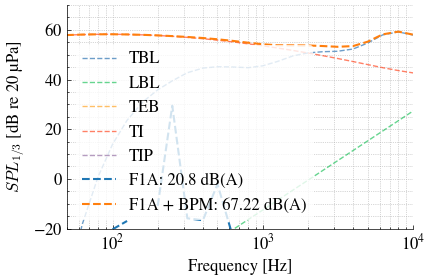

In [11]:
color_5e = 'tab:blue'
color_7e = 'tab:orange'
color_8e = 'tab:green'

# Values for labels

clean_ospl_exp = calc_oaspl(clean_spl_3oct.squeeze(), propeller.third_octave_freqs, weighted=False)
clean_oaspl_exp = calc_oaspl(clean_spl_3oct.squeeze(), propeller.third_octave_freqs, weighted=True)


plt.figure(figsize=(4.5, 3))
# plt.figure(figsize=(10, 6))

# Components (keeping these simpler to avoid legend clutter)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['tbl'][:, 0], '--', alpha=0.6, label='TBL')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['lbl'][:, 0], '--', alpha=0.6, label='LBL')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['teb'][:, 0], '--', alpha=0.6, label='TEB')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['ti'][:, 0], '--', alpha=0.6, label='TI')
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.spl_breakdown['tv'][:, 0], '--', alpha=0.6, label='TIP')

# plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), clean_spl_3oct, '-', 
#              label=f'Meas {clean_oaspl_exp:.2f} dB(A)', color=color_8e, linewidth=1.5)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.third_octave_f1a_spl.cpu().numpy()[:, 0], '--',
             label=f'F1A: {propeller.third_octave_f1a_oaspl.item():.1f} dB(A)', color=color_5e, linewidth=1.5)
plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), propeller.third_octave_total_spl.cpu().numpy()[:, 0], '--', 
             label=f'F1A + BPM: {propeller.third_octave_total_oaspl.item():.2f} dB(A)', color=color_7e, linewidth=1.5)

# plt.semilogx(propeller.third_octave_freqs.cpu().numpy(), exp_spl_3oct, '-', 
#              label=f'Meas {oaspl_exp:.2f} dB(A)', linewidth=1.5)

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('$SPL_{1/3}$ [dB re 20 µPa]', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='both', ls=':')
plt.legend(loc='lower left', fontsize=12, frameon=True, edgecolor='none')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().tick_params(top=False, right=False, which='both')
plt.xlim(50, 10000)
plt.ylim(-20, 70)
plt.tight_layout()
plt.savefig('../Figures/BPM_val.pdf', dpi=200)
plt.show()

In [12]:
propeller.spl_breakdown['tv']

array([[-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.],
       [-120.]], dtype=float32)